In [3]:
import sys
!{sys.executable} -m pip install roboflow

  Using cached roboflow-1.4.0-py3-none-any.whl.metadata (11 kB)
  Using cached numpy-2.3.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached pi_heif-1.4.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.3 kB)
  Using cached pillow_avif_plugin-1.6.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (2.2 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-non

In [5]:
from roboflow import Roboflow
rf = Roboflow(api_key="LqYmST34iaJPPciCks7U")
project = rf.workspace("ahmed-jawad-owrri").project("bahrain_foods")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to Bahrain_Foods-1 in yolov8:: 100%|█| 539/539 [


# Bahrain Food Detector — YOLOv8 training pipeline

**Context (from `MODEL_REPORT.md`):** `food_model.pkl` is a **ViT-B/16 classifier**
(241 Chinese-food classes), *not* an object detector — it cannot be converted to
YOLO weights. This notebook therefore trains a proper **YOLOv8 object detector**
on the Roboflow `bahrain_foods` dataset (9 classes, bounding-box labels):

- balaleet, egg_tomato, fish, harees, karak, liver, ma3krona, nakhaj, tikka

**Flow:** label-safe data augmentation (noise / color / blur — no rotations or
crops that would desync bounding boxes) → train YOLOv8n → save `food_yolo_best.pt`
for detection. This notebook is fully self-contained: run it top-to-bottom.



In [1]:
import sys
!{sys.executable} -m pip install -q ultralytics



In [1]:
import os, glob, random, shutil, zlib
import numpy as np
import cv2
import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))



torch: 2.13.0+cu130
CUDA available: False


## 1. Dataset sanity check

Verify every image has a matching label file and print the per-class box
distribution (the augmentation step must not change any of this).



In [2]:
from collections import Counter

BASE = "Bahrain_Foods-1"
CLASSES = ["balaleet", "egg_tomato", "fish", "harees", "karak", "liver", "ma3krona", "nakhaj", "tikka"]

for split in ("train", "valid", "test"):
    img_dir, lab_dir = f"{BASE}/{split}/images", f"{BASE}/{split}/labels"
    imgs = sorted(os.listdir(img_dir))
    labs = sorted(os.listdir(lab_dir))
    stems_i = {os.path.splitext(f)[0] for f in imgs}
    stems_l = {os.path.splitext(f)[0] for f in labs}
    boxes = Counter()
    for lf in labs:
        for line in open(f"{lab_dir}/{lf}"):
            parts = line.split()
            if parts:
                boxes[int(parts[0])] += 1
    print(f"[{split}] images={len(imgs)} labels={len(labs)} "
          f"missing_labels={len(stems_i - stems_l)} orphan_labels={len(stems_l - stems_i)} boxes={sum(boxes.values())}")
    print("   ", {CLASSES[k]: v for k, v in sorted(boxes.items())})



[train] images=187 labels=187 missing_labels=0 orphan_labels=0 boxes=239
    {'balaleet': 23, 'egg_tomato': 21, 'fish': 21, 'harees': 23, 'karak': 31, 'liver': 16, 'ma3krona': 25, 'nakhaj': 55, 'tikka': 24}
[valid] images=53 labels=53 missing_labels=0 orphan_labels=0 boxes=55
    {'balaleet': 6, 'egg_tomato': 4, 'fish': 6, 'harees': 6, 'karak': 8, 'liver': 10, 'ma3krona': 6, 'nakhaj': 5, 'tikka': 4}
[test] images=27 labels=27 missing_labels=0 orphan_labels=0 boxes=31
    {'balaleet': 1, 'egg_tomato': 5, 'fish': 2, 'harees': 1, 'karak': 7, 'liver': 6, 'ma3krona': 2, 'nakhaj': 4, 'tikka': 3}


## 2. Label-safe data augmentation

Only pixel-space transforms are applied to the **training set**, so bounding-box
labels stay valid:

- **Noise:** Gaussian noise, salt & pepper
- **Color:** brightness, contrast, saturation, hue jitter
- **Blur / sharpness / contrast enhancement** (CLAHE)
- **Horizontal flip** — the only geometric transform; it is label-safe because the
  box `x_center` is simply mirrored (`xc -> 1 - xc`)

Excluded on purpose: rotations, scaling, crops and translations — they would
misalign the boxes without recomputing them. Each variant is generated from a
seeded RNG so the augmented dataset is reproducible.



In [3]:
def add_gaussian_noise(img, sigma):
    noise = np.random.normal(0, sigma * 255, img.shape)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)


def add_salt_pepper(img, prob):
    out = img.copy()
    mask = np.random.rand(*img.shape[:2]) < prob
    vals = np.where(np.random.rand(int(mask.sum())) > 0.5, 255, 0).astype(np.uint8)
    out[mask] = vals[:, None]
    return out


def adjust_brightness(img, factor):
    return np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)


def adjust_contrast(img, factor):
    mean = img.mean()
    return np.clip((img.astype(np.float32) - mean) * factor + mean, 0, 255).astype(np.uint8)


def adjust_saturation(img, factor):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[..., 1] = np.clip(hsv[..., 1] * factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)


def adjust_hue(img, delta):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.int16)
    hsv[..., 0] = (hsv[..., 0] + delta) % 180
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)


def gaussian_blur(img, ksize):
    return cv2.GaussianBlur(img, (ksize, ksize), 0)


def sharpen(img, amount):
    blur = cv2.GaussianBlur(img, (0, 0), 3)
    return cv2.addWeighted(img, 1 + amount, blur, -amount, 0)


def apply_clahe(img, clip=2.0, grid=(8, 8)):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    lab[..., 0] = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid).apply(lab[..., 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def hflip(img, boxes):
    flipped = cv2.flip(img, 1)
    return flipped, [[c, 1.0 - xc, yc, w, h] for c, xc, yc, w, h in boxes]


AUG_POOL = ["brightness", "contrast", "saturation", "hue",
            "gaussian_noise", "salt_pepper", "blur", "sharpen", "clahe", "hflip"]


def augment_image(img, boxes, rng):
    img = img.copy()
    boxes = [list(b) for b in boxes]
    for op in rng.sample(AUG_POOL, k=rng.randint(2, 4)):
        if op == "brightness":
            img = adjust_brightness(img, rng.uniform(0.75, 1.35))
        elif op == "contrast":
            img = adjust_contrast(img, rng.uniform(0.75, 1.35))
        elif op == "saturation":
            img = adjust_saturation(img, rng.uniform(0.6, 1.6))
        elif op == "hue":
            img = adjust_hue(img, rng.randint(-15, 15))
        elif op == "gaussian_noise":
            img = add_gaussian_noise(img, rng.uniform(0.01, 0.06))
        elif op == "salt_pepper":
            img = add_salt_pepper(img, rng.uniform(0.001, 0.005))
        elif op == "blur":
            img = gaussian_blur(img, rng.choice([3, 5]))
        elif op == "sharpen":
            img = sharpen(img, rng.uniform(0.3, 0.9))
        elif op == "clahe":
            img = apply_clahe(img)
        elif op == "hflip":
            img, boxes = hflip(img, boxes)
    return img, boxes



## 3. Generate the augmented dataset

Writes `AUG_PER_IMAGE` variants of every training image to
`Bahrain_Foods-1/train_aug/` (labels copied with the flip-adjusted box) and
creates `data_aug.yaml`, which points the trainer at **original + augmented**
train images and the original validation split. Re-running this cell
regenerates the identical dataset (seeded).



In [4]:
import yaml

AUG_PER_IMAGE = 6
TRAIN_IMG, TRAIN_LAB = f"{BASE}/train/images", f"{BASE}/train/labels"
AUG_IMG, AUG_LAB = f"{BASE}/train_aug/images", f"{BASE}/train_aug/labels"

os.makedirs(AUG_IMG, exist_ok=True)
os.makedirs(AUG_LAB, exist_ok=True)


def read_boxes(path):
    boxes = []
    for line in open(path):
        parts = line.split()
        if len(parts) == 5:
            boxes.append([int(parts[0])] + [float(p) for p in parts[1:]])
    return boxes


def write_boxes(boxes, path):
    with open(path, "w") as f:
        for c, xc, yc, w, h in boxes:
            f.write(f"{c} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")


count = 0
for img_file in sorted(os.listdir(TRAIN_IMG)):
    stem = os.path.splitext(img_file)[0]
    img = cv2.imread(os.path.join(TRAIN_IMG, img_file))
    if img is None:
        continue
    boxes = read_boxes(os.path.join(TRAIN_LAB, stem + ".txt"))
    key = zlib.crc32(stem.encode())
    for v in range(AUG_PER_IMAGE):
        rng = random.Random((SEED * 1_000_003 + key * 31 + v) % (2**31))
        aug_img, aug_boxes = augment_image(img, boxes, rng)
        out_stem = f"{stem}_aug{v}"
        cv2.imwrite(os.path.join(AUG_IMG, out_stem + ".jpg"), aug_img)
        write_boxes(aug_boxes, os.path.join(AUG_LAB, out_stem + ".txt"))
        count += 1
print("wrote", count, "augmented images")
print("train images now:", count + len(os.listdir(TRAIN_IMG)))

yaml_data = {
    "path": BASE,
    "train": ["train/images", "train_aug/images"],
    "val": "valid/images",
    "test": "test/images",
    "nc": len(CLASSES),
    "names": CLASSES,
}
with open(f"{BASE}/data_aug.yaml", "w") as f:
    yaml.safe_dump(yaml_data, f, sort_keys=False)
print("wrote", f"{BASE}/data_aug.yaml")



wrote 1122 augmented images
train images now: 1309
wrote Bahrain_Foods-1/data_aug.yaml


## 4. Preview the augmentation

Same image + its boxes drawn on the original and 3 generated variants
(same seed as the generator). Boxes must stay aligned on the food in all panels.



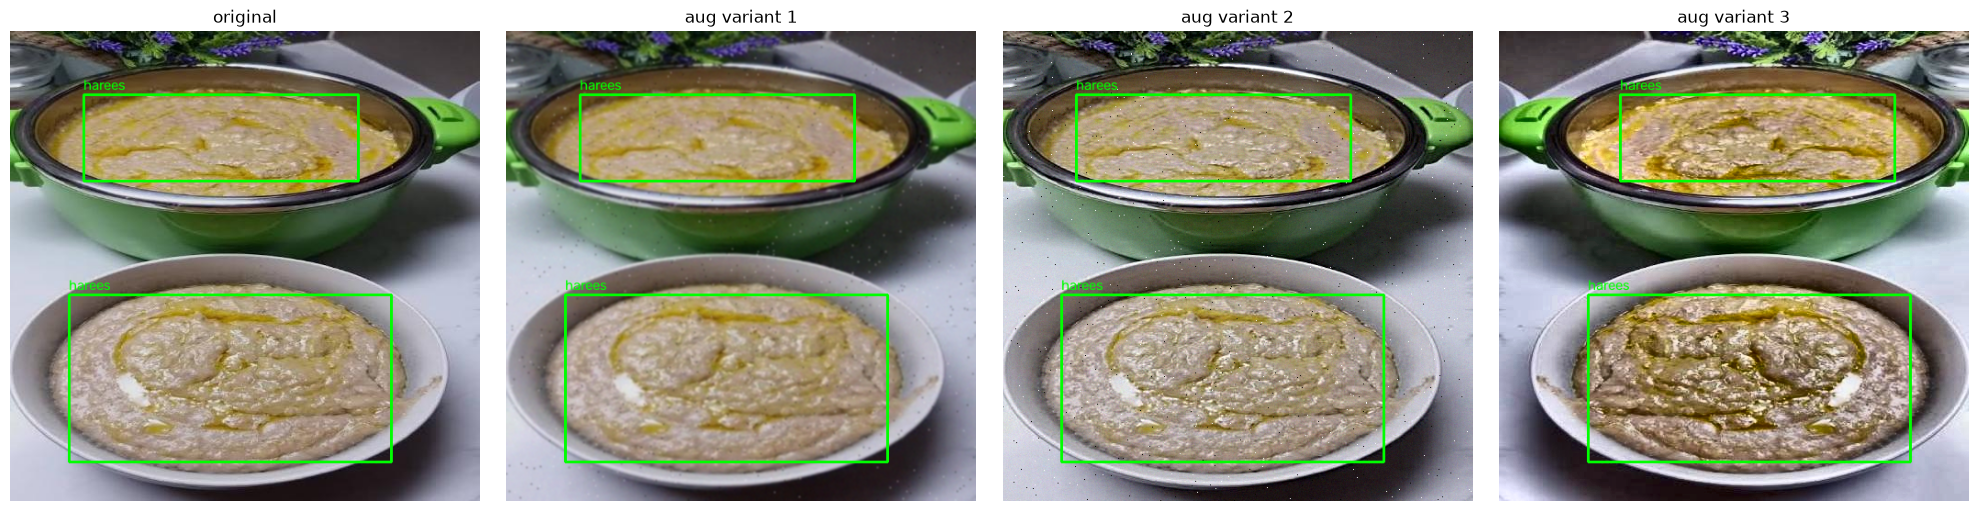

saved aug_preview.png


In [6]:
import matplotlib.pyplot as plt


def draw_boxes(img, boxes):
    out = img.copy()
    for c, xc, yc, w, h in boxes:
        x1, y1 = int((xc - w / 2) * out.shape[1]), int((yc - h / 2) * out.shape[0])
        x2, y2 = int((xc + w / 2) * out.shape[1]), int((yc + h / 2) * out.shape[0])
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, CLASSES[c], (x1, max(0, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    return out


sample = sorted(os.listdir(TRAIN_IMG))[0]
img = cv2.imread(os.path.join(TRAIN_IMG, sample))
boxes = read_boxes(os.path.join(TRAIN_LAB, os.path.splitext(sample)[0] + ".txt"))
key = zlib.crc32(os.path.splitext(sample)[0].encode())
panels = [draw_boxes(img, boxes)]
for v in range(3):
    rng = random.Random((SEED * 1_000_003 + key * 31 + v) % (2**31))
    a, b_ = augment_image(img, boxes, rng)
    panels.append(draw_boxes(a, b_))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, panel, title in zip(axes, panels, ["original"] + [f"aug variant {i+1}" for i in range(3)]):
    ax.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig("aug_preview.png", dpi=100)
plt.show()
print("saved aug_preview.png")



## 5. Train YOLOv8n (runs best on a GPU)

Pretrained COCO weights are downloaded automatically. `yolov8n` is the nano
variant — the right size for a ~1,300-image dataset. Training on CPU works but
is slow; on a GPU this takes roughly 1-2 hours for 150 epochs at 640px.



In [ ]:
model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{BASE}/data_aug.yaml",
    epochs=150,
    imgsz=640,
    batch=16,
    patience=30,
    cache=True,
    seed=SEED,
    project="runs",
    name="food_yolov8n",
)



## 6. Save the final model

`best.pt` is copied to the project root as `food_yolo_best.pt` — usable anywhere
with `YOLO("food_yolo_best.pt")`. An optional ONNX export (for deployment with
OpenCV/TensorRT) is included.



In [ ]:
best_pt = sorted(glob.glob("runs/food_yolov8n/weights/best.pt"))[-1]
shutil.copy(best_pt, "food_yolo_best.pt")
print(f"mAP50: {results.box.map50:.4f} | mAP50-95: {results.box.map:.4f}")
print(f"saved food_yolo_best.pt ({os.path.getsize('food_yolo_best.pt') / 1e6:.1f} MB)")

best_model = YOLO("food_yolo_best.pt")
best_model.export(format="onnx", imgsz=640)
print("also exported food_yolo_best.onnx")



## 7. Demo: detection on test images



In [ ]:
demo = YOLO("food_yolo_best.pt")
test_imgs = sorted(glob.glob(f"{BASE}/test/images/*"))

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for ax, f in zip(axes.flat, test_imgs[:9]):
    r = demo.predict(f, imgsz=640, conf=0.25, verbose=False)[0]
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(f)[:24], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()



## 8. Stage 2 — fine-tune the ViT classifier (detect → crop → classify)

`food_model.pkl` is a ViT-B/16 **classifier** — it can't draw boxes (that's what
YOLO is for), but it's excellent at naming a food crop. Following the report's
two-stage recommendation:

1. **Crops:** the YOLO labels already tell us where the food is, so box crops
   from `train/` are the classifier's training set (val crops = evaluation).
2. **Fine-tune:** swap the 241 Chinese-food head for a 9-class head, freeze the
   backbone (linear probe), then optionally unfreeze the last 2 blocks at lr 1e-5
   (mirrors the paper's recipe, conservatively). Only ~86M-param backbone stays
   frozen, so this trains fast and won't overfit.
3. Rotation *is* fine here — classification crops have no boxes to keep aligned.
4. Save `food_classifier.pt`; final demo combines both stages.



In [5]:
import sys
!{sys.executable} -m pip install -q timm



In [6]:
from PIL import Image


def load_crops(split):
    crops, labels = [], []
    for img_file in sorted(glob.glob(f"{BASE}/{split}/images/*")):
        stem = os.path.splitext(os.path.basename(img_file))[0]
        img = Image.open(img_file).convert("RGB")
        W, H = img.size
        for c, xc, yc, w, h in read_boxes(os.path.join(f"{BASE}/{split}/labels", stem + ".txt")):
            x1, y1 = int((xc - w / 2) * W), int((yc - h / 2) * H)
            x2, y2 = int((xc + w / 2) * W), int((yc + h / 2) * H)
            crop = img.crop((max(0, x1), max(0, y1), min(W, x2), min(H, y2)))
            if crop.width < 10 or crop.height < 10:
                continue
            crops.append(crop)
            labels.append(c)
    return crops, labels


train_crops, train_cls = load_crops("train")
val_crops, val_cls = load_crops("valid")
print("train crops:", len(train_crops), "| val crops:", len(val_crops))
print("train class dist:", dict(sorted(Counter(train_cls).items())))
print("val class dist:", dict(sorted(Counter(val_cls).items())))



train crops: 238 | val crops: 55
train class dist: {0: 23, 1: 21, 2: 21, 3: 23, 4: 31, 5: 16, 6: 25, 7: 54, 8: 24}
val class dist: {0: 6, 1: 4, 2: 6, 3: 6, 4: 8, 5: 10, 6: 6, 7: 5, 8: 4}


In [7]:
import timm
import torch.nn as nn
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

vit = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=241)
vit.load_state_dict(torch.load("food_model.pkl", map_location="cpu"))
print(f"loaded food_model.pkl 1:1 ({sum(p.numel() for p in vit.parameters()) / 1e6:.1f} M params)")

vit.head = nn.Linear(vit.embed_dim, len(CLASSES))
print("replaced 241-class head with", len(CLASSES), "-class head:", vit.head)



loaded food_model.pkl 1:1 (86.0 M params)
replaced 241-class head with 9 -class head: Linear(in_features=768, out_features=9, bias=True)


In [8]:
from torch.utils.data import DataLoader, TensorDataset

PROBE_EPOCHS = 12
FINETUNE_EPOCHS = 6
UNFREEZE_LAST_BLOCKS = 2
FINETUNE_LR = 1e-5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("classifier device:", device)
vit = vit.to(device)


def prep(crops, labels, tf):
    X = torch.stack([tf(c) for c in crops])
    return X, torch.tensor(labels)


Xtr, ytr = prep(train_crops, train_cls, train_tf)
Xva, yva = prep(val_crops, val_cls, val_tf)
train_dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=16, shuffle=True)
val_dl = DataLoader(TensorDataset(Xva, yva), batch_size=16)


def evaluate(model, dl):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in dl:
            correct += (model(xb.to(device)).argmax(1) == yb.to(device)).sum().item()
            total += len(yb)
    return correct / total


def train_stage(model, dl, val_dl, epochs, lr, unfreeze):
    for p in model.parameters():
        p.requires_grad = False
    if unfreeze:
        for p in model.blocks[-unfreeze:].parameters():
            p.requires_grad = True
    for p in model.head.parameters():
        p.requires_grad = True
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    best = 0.0
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(yb)
        sched.step()
        acc = evaluate(model, val_dl)
        best = max(best, acc)
        print(f"epoch {epoch:2d} | loss {total_loss / len(dl.dataset):.4f} | val acc {acc:.4f}")
    return best


print("--- linear probe (backbone frozen) ---")
best_acc = train_stage(vit, train_dl, val_dl, PROBE_EPOCHS, 1e-3, unfreeze=None)
if UNFREEZE_LAST_BLOCKS:
    print(f"--- unfreeze last {UNFREEZE_LAST_BLOCKS} blocks (lr {FINETUNE_LR}) ---")
    best_acc = max(best_acc, train_stage(vit, train_dl, val_dl, FINETUNE_EPOCHS, FINETUNE_LR, unfreeze=UNFREEZE_LAST_BLOCKS))
print(f"best val acc: {best_acc:.4f}")



classifier device: cpu


--- linear probe (backbone frozen) ---


epoch  1 | loss 1.2822 | val acc 0.8182


epoch  2 | loss 0.0942 | val acc 0.8364


epoch  3 | loss 0.0330 | val acc 0.8909


...

epoch  2 | loss 0.0014 | val acc 0.9091


epoch  3 | loss 0.0006 | val acc 0.9091


epoch  4 | loss 0.0004 | val acc 0.9273


epoch  5 | loss 0.0003 | val acc 0.9273


epoch  6 | loss 0.0003 | val acc 0.9273
best val acc: 0.9273


In [9]:
torch.save({
    "state_dict": vit.state_dict(),
    "class_names": CLASSES,
    "val_acc": best_acc,
}, "food_classifier.pt")
print(f"saved food_classifier.pt ({os.path.getsize('food_classifier.pt') / 1e6:.1f} MB)")

vit.eval()
per_class = Counter()
correct_by_class = Counter()
with torch.no_grad():
    for xb, yb in val_dl:
        preds = vit(xb.to(device)).argmax(1).cpu()
        for p, t in zip(preds, yb):
            per_class[int(t)] += 1
            correct_by_class[int(t)] += int(p == t)
print("per-class val accuracy:")
for c in range(len(CLASSES)):
    total = per_class[c]
    if total:
        print(f"  {CLASSES[c]:12s} {correct_by_class[c] / total:.2f} ({correct_by_class[c]}/{total})")



saved food_classifier.pt (343.3 MB)


per-class val accuracy:
  balaleet     1.00 (6/6)
  egg_tomato   1.00 (4/4)
  fish         1.00 (6/6)
  harees       1.00 (6/6)
  karak        1.00 (8/8)
  liver        0.60 (6/10)
  ma3krona     1.00 (6/6)
  nakhaj       1.00 (5/5)
  tikka        1.00 (4/4)


## 9. Demo: two-stage detection (YOLO finds the food, ViT names it)

The detector's box label is replaced by the classifier's prediction, giving the
best of both models per MODEL_REPORT.md §4.



In [ ]:
det = YOLO("food_yolo_best.pt")
clf = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=len(CLASSES))
clf.load_state_dict(torch.load("food_classifier.pt", map_location="cpu")["state_dict"])
clf.eval()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, f in zip(axes, sorted(glob.glob(f"{BASE}/test/images/*"))[:3]):
    r = det.predict(f, imgsz=640, conf=0.25, verbose=False)[0]
    img = Image.open(f).convert("RGB")
    out = cv2.imread(f)
    with torch.no_grad():
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            crop = img.crop((x1, y1, x2, y2))
            pred = CLASSES[clf(val_tf(crop).unsqueeze(0)).argmax(1).item()]
            cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(out, pred, (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    ax.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(f)[:24], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

